<a href="https://colab.research.google.com/github/Suman18-bit/NLP_CHALANGES/blob/main/NLP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud matplotlib
%matplotlib inline

In [6]:
df = pd.read_csv("/content/ch4_feedback_data.csv",header=None)

In [7]:
df.head()

,0,1
0,Your products are excellent. I really love the...,delivery to my location in Los Angeles was a ...
1,The customer service team in New York was help...,NaN
2,The new features in the latest release are fan...,NaN
3,The product didn't meet my expectations,and I'm disappointed. I hope you can address ...
4,Your products are not good. I really don't lik...,delivery to my location in Los Angeles was a ...


In [9]:
from transformers import pipeline, DistilBertTokenizer
from transformers.models.distilbert import DistilBertModel

In [10]:
model = DistilBertModel.from_pretrained('distilbert-base-uncased')
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [11]:
sentiment_analysis_bert = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
sentiment_results_bert = []
for index, row in df.iterrows():
    text = row[0]
    bert_result = sentiment_analysis_bert(text)[0]
    sentiment_label_bert = bert_result['label']
    sentiment_score_bert = bert_result['score']
    sentiment_results_bert.append({"Text": text, "Sentiment Score": sentiment_score_bert, "Sentiment Label": sentiment_label_bert})
for result in sentiment_results_bert:
    print(f"Text: {result['Text']}")
    print(f"Sentiment Score: {result['Sentiment Score']}")
    print(f"Sentiment Label: {result['Sentiment Label']}")
    print("  ")
sentiment_df_bert = pd.DataFrame(sentiment_results_bert)

sentiment_df_bert.to_csv("sentiment_results_bert.csv", index=False)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Text: Your products are excellent. I really love the quality! However
Sentiment Score: 0.5744264721870422
Sentiment Label: 5 stars
  
Text: The customer service team in New York was helpful in resolving my issue. I appreciate the assistance. brian@email.com
Sentiment Score: 0.5543172955513
Sentiment Label: 4 stars
  
Text: The new features in the latest release are fantastic! They have greatly improved the user experience in San Francisco.
Sentiment Score: 0.8357025384902954
Sentiment Label: 5 stars
  
Text: The product didn't meet my expectations
Sentiment Score: 0.4780276417732239
Sentiment Label: 2 stars
  
Text: Your products are not good. I really don't like the quality! However
Sentiment Score: 0.5138059854507446
Sentiment Label: 2 stars
  
Text: The customer service team in San Francisco was not helpful in resolving my issue. But
Sentiment Score: 0.5047701597213745
Sentiment Label: 3 stars
  
Text: The new features in the latest release are not fantastic! They have not greatly i

In [12]:
sentiment_results_bert = pd.read_csv("/content/sentiment_results_bert.csv")

In [13]:
sentiment_results_bert

,Text,Sentiment Score,Sentiment Label
0,Your products are excellent. I really love the...,0.574426,5 stars
1,The customer service team in New York was help...,0.554317,4 stars
2,The new features in the latest release are fan...,0.835703,5 stars
3,The product didn't meet my expectations,0.478028,2 stars
4,Your products are not good. I really don't lik...,0.513806,2 stars
5,The customer service team in San Francisco was...,0.504770,3 stars
6,The new features in the latest release are not...,0.598198,3 stars
7,The product didn't meet my expectations,0.478028,2 stars


In [14]:
from wordcloud import WordCloud

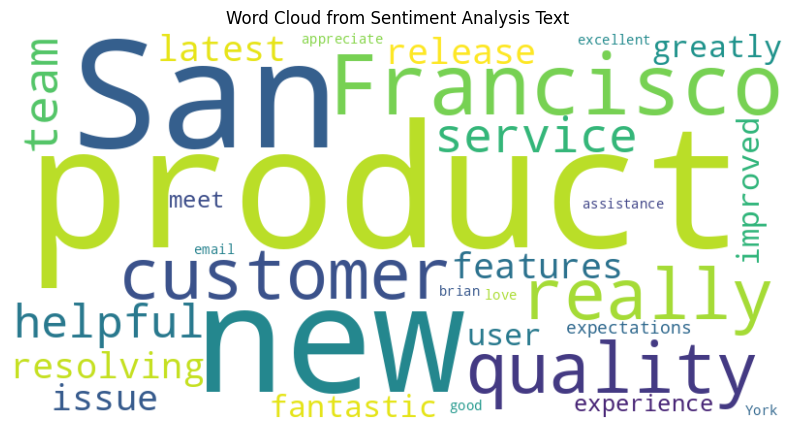

In [19]:

from wordcloud import WordCloud
text_combined = ' '.join(sentiment_df_bert['Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Sentiment Analysis Text')
plt.show()

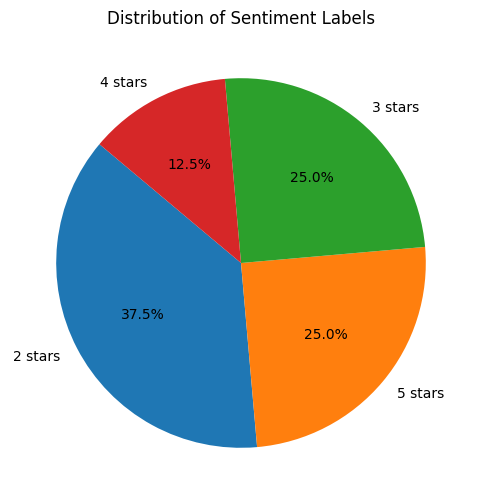

In [20]:
sentiment_label_counts = sentiment_df_bert['Sentiment Label'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(sentiment_label_counts, labels=sentiment_label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Sentiment Labels')
plt.show()

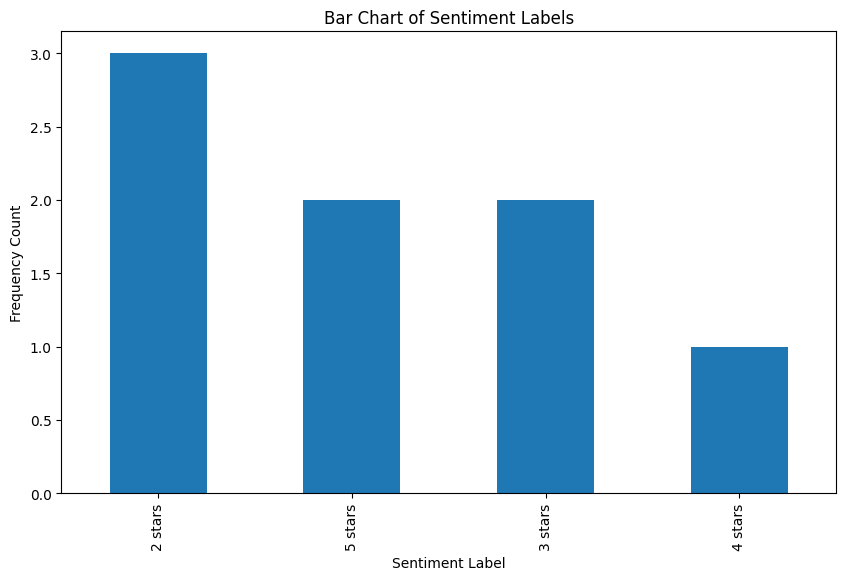

In [21]:
sentiment_label_counts = sentiment_df_bert['Sentiment Label'].value_counts()
plt.figure(figsize=(10, 6))
sentiment_label_counts.plot(kind='bar', stacked=True)
plt.title('Bar Chart of Sentiment Labels')
plt.xlabel('Sentiment Label')
plt.ylabel('Frequency Count')
plt.show()